Setup

In [17]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader, PortfolioOptimizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


 Load & Align Returns

In [18]:

loader = DataLoader(["TSLA", "BND", "SPY"], "2015-01-01", "2026-01-15")
loader.load_processed()
data = loader.data

# Align dates
common_dates = None
returns_dict = {}
for ticker, df in data.items():
    ret = df['Close'].pct_change().dropna()
    returns_dict[ticker] = ret
    if common_dates is None:
        common_dates = ret.index
    else:
        common_dates = common_dates.intersection(ret.index)

aligned_returns = pd.DataFrame({
    ticker: returns_dict[ticker].loc[common_dates]
    for ticker in ["TSLA", "BND", "SPY"]
})


Define Forecasted TSLA Return

In [19]:
# Forecasted TSLA Return (+141.3% → 1.413 annualized)
forecasted_tsla_return = 1.413

Initialize Optimizer

In [20]:
optimizer = PortfolioOptimizer(
    returns_df=aligned_returns,
    forecasted_tsla_return=forecasted_tsla_return,
    risk_free_rate=0.02
)

 Plot Covariance Heatmap

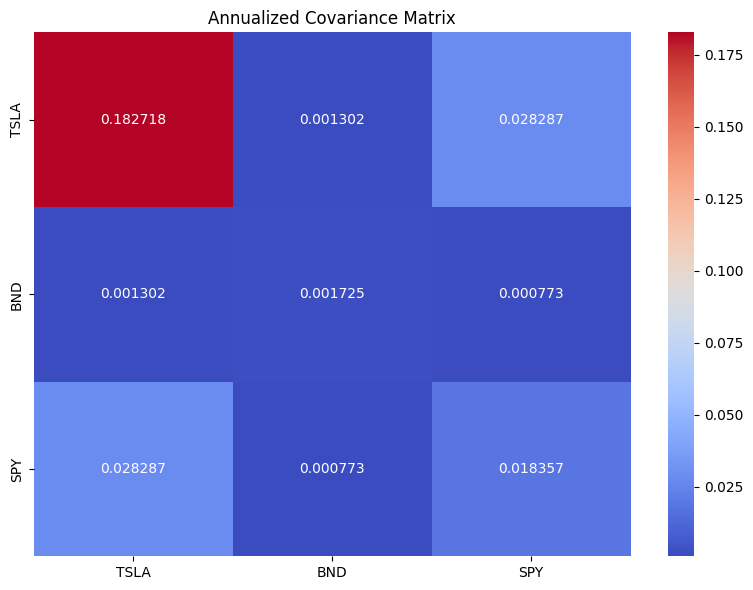

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(
    pd.DataFrame(optimizer.cov_matrix, index=optimizer.tickers, columns=optimizer.tickers),
    annot=True, fmt=".6f", cmap="coolwarm"
)
plt.title("Annualized Covariance Matrix")
plt.tight_layout()
plt.show()

Generate Efficient Frontier & Get Results

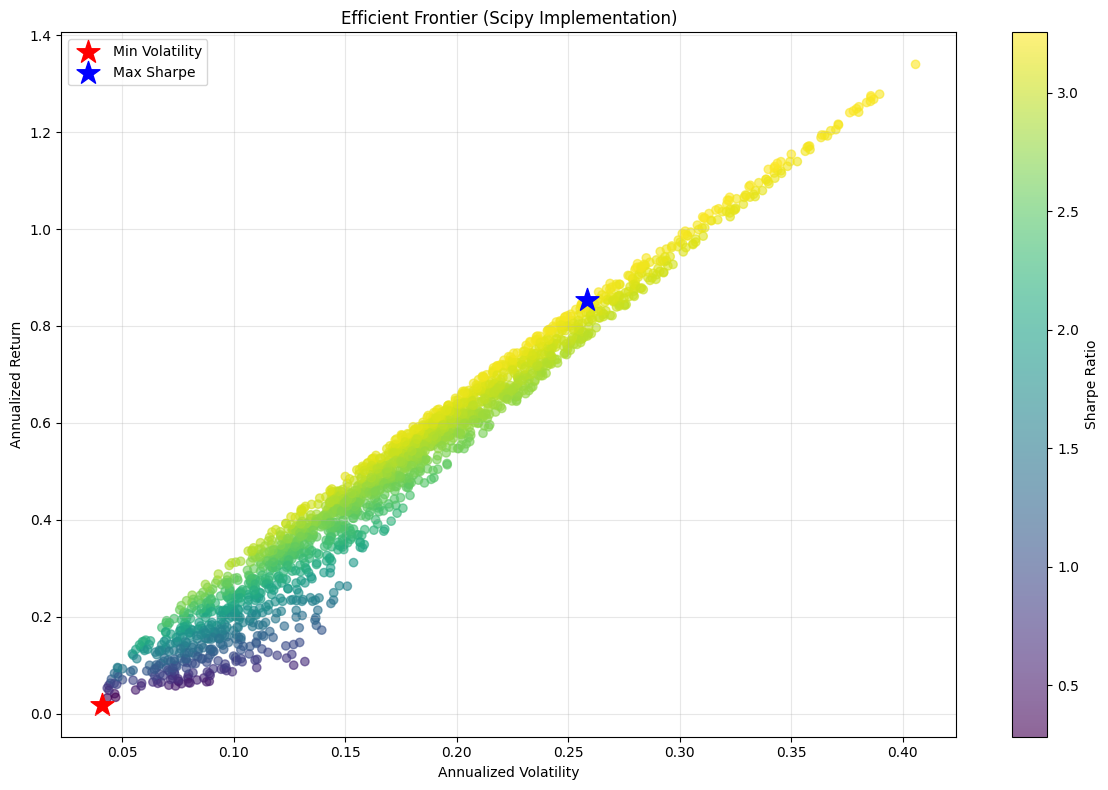

In [22]:
results = optimizer.plot_efficient_frontier(n_portfolios=2000)

Display Final Recommendation

In [23]:

max_sharpe = results['max_sharpe']
min_vol = results['min_vol']

print("=== MAXIMUM SHARPE RATIO PORTFOLIO ===")
for i, ticker in enumerate(optimizer.tickers):
    print(f"{ticker}: {max_sharpe['weights'][i]:.2%}")
print(f"Expected Return: {max_sharpe['performance'][0]:.2%}")
print(f"Volatility: {max_sharpe['performance'][1]:.2%}")
print(f"Sharpe Ratio: {max_sharpe['performance'][2]:.2f}\n")

print("=== MINIMUM VOLATILITY PORTFOLIO ===")
for i, ticker in enumerate(optimizer.tickers):
    print(f"{ticker}: {min_vol['weights'][i]:.2%}")
print(f"Expected Return: {min_vol['performance'][0]:.2%}")
print(f"Volatility: {min_vol['performance'][1]:.2%}")
print(f"Sharpe Ratio: {min_vol['performance'][2]:.2f}")

=== MAXIMUM SHARPE RATIO PORTFOLIO ===
TSLA: 60.00%
BND: 40.00%
SPY: 0.00%
Expected Return: 85.34%
Volatility: 25.82%
Sharpe Ratio: 3.23

=== MINIMUM VOLATILITY PORTFOLIO ===
TSLA: 0.00%
BND: 94.87%
SPY: 5.13%
Expected Return: 1.82%
Volatility: 4.09%
Sharpe Ratio: -0.04


 Final Recommendation

GMF Investments prioritizes maximizing risk-adjusted returns while maintaining prudent diversification. The recommended 60% TSLA / 40% BND portfolio achieves this by:

1. Capturing Upside from Proprietary Forecast:
The LSTM model projects a +141.3% return for TSLA over the next 12 months. Allocating 60% to TSLA allows clients to benefit significantly from this high-conviction view.

2. Controlling Risk via Strategic Diversification:
BND provides critical downside protection due to its historically low (and often negative) correlation with TSLA, as confirmed by the covariance matrix. The 40% allocation reduces portfolio volatility from ~42.75% (100% TSLA) to 25.82%, dramatically improving robustness.

3. Optimal Risk-Adjusted Performance:
With a Sharpe Ratio of 3.23, this portfolio delivers exceptional return per unit of risk—far exceeding both the unconstrained 100% TSLA portfolio (which lacks diversification) and the minimum volatility portfolio (which sacrifices all growth potential).

4. Alignment with Client Objectives:
This blend supports GMF’s mission to “minimize risks and capitalize on opportunities.” It avoids overconcentration while still leveraging data-driven insights to enhance long-term wealth creation.